In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler
import copy
import seaborn as sns
import tensorflow as tf
from sklearn.linear_model import LinearRegression

In [40]:
dataset_cols = ['bike_count', 'hour', 'temp', 'humidity', 'wind', 'visibility', 'dew_pt_temp', 'radiation', 'rain', 'snow', 'functional']

In [41]:
df = pd.read_csv('SeoulBikeData.csv', encoding='latin1').drop(['Date', 'Holiday', 'Seasons'], axis=1)

In [42]:
df.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Functioning Day
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Yes
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Yes
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Yes
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Yes
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Yes


In [43]:
df.columns = dataset_cols
df['functional'] = (df['functional'] == 'Yes').astype(int)
df = df[df['hour'] == 12]
df = df.drop(['hour'], axis = 1)

In [44]:
df.head()

,bike_count,temp,humidity,wind,visibility,dew_pt_temp,radiation,rain,snow,functional
12,449,1.7,23,1.4,2000,-17.2,1.11,0.0,0.0,1
36,479,4.3,41,1.3,1666,-7.8,1.09,0.0,0.0,1
60,333,5.8,85,1.7,349,3.4,0.43,0.0,0.0,1
84,393,-0.3,38,4.8,1823,-12.9,1.11,0.0,0.0,1
108,321,-2.3,25,0.0,1962,-19.7,0.00,0.0,0.0,1


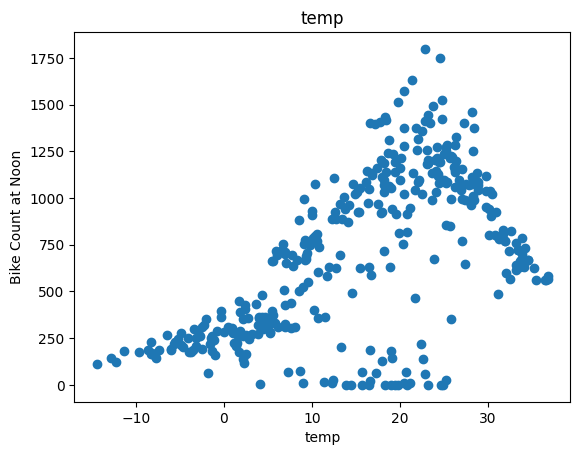

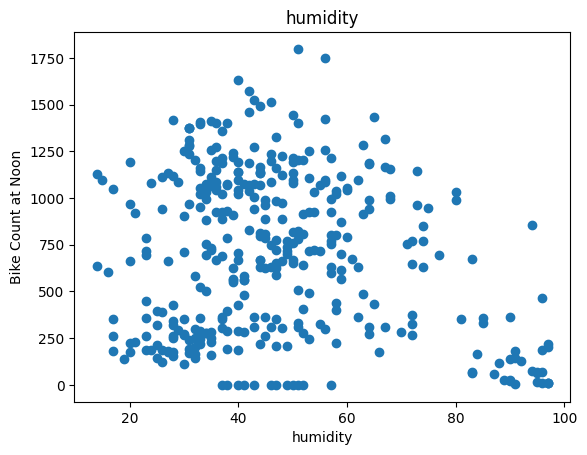

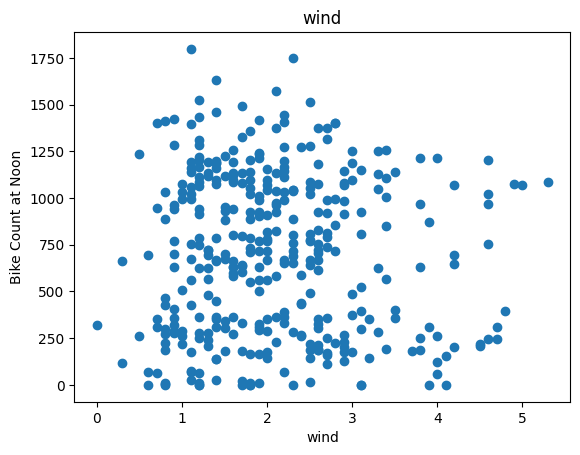

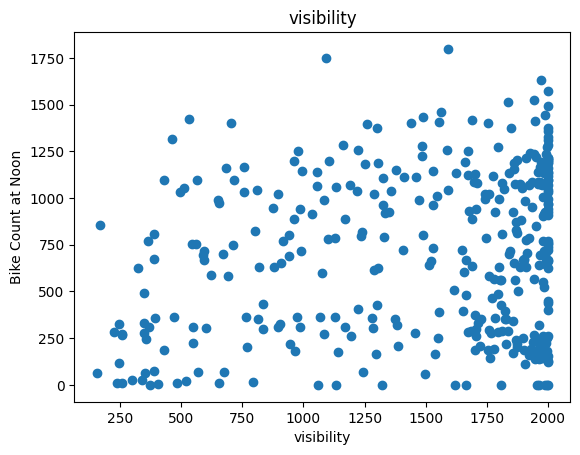

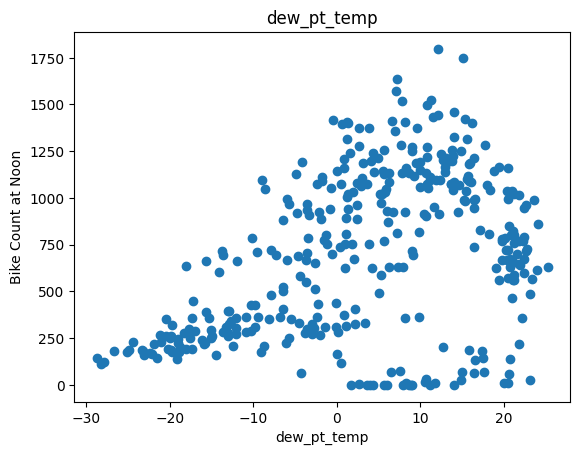

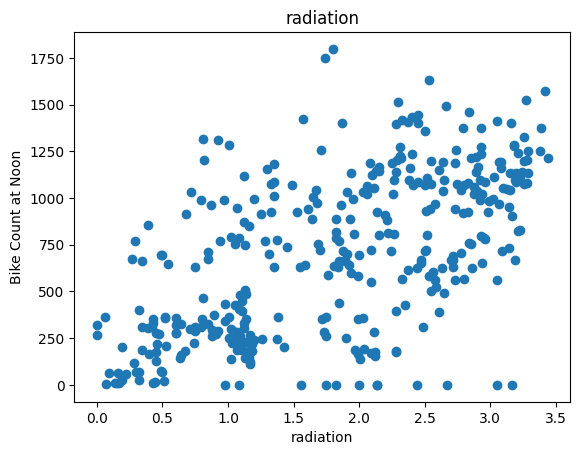

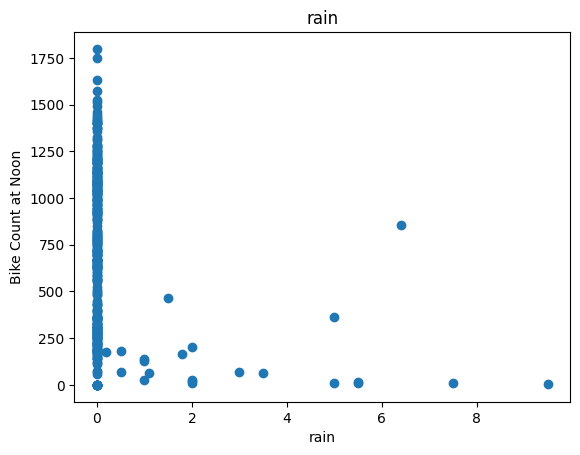

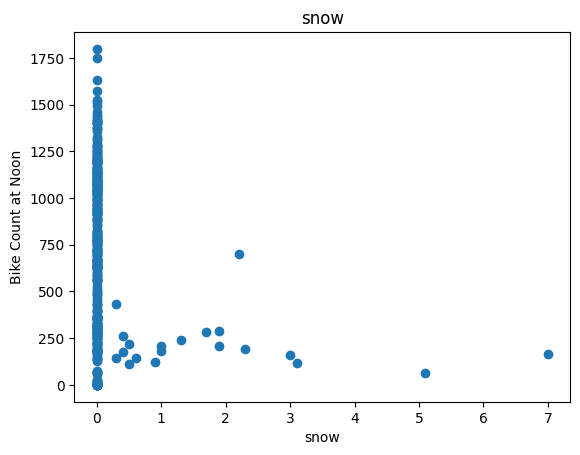

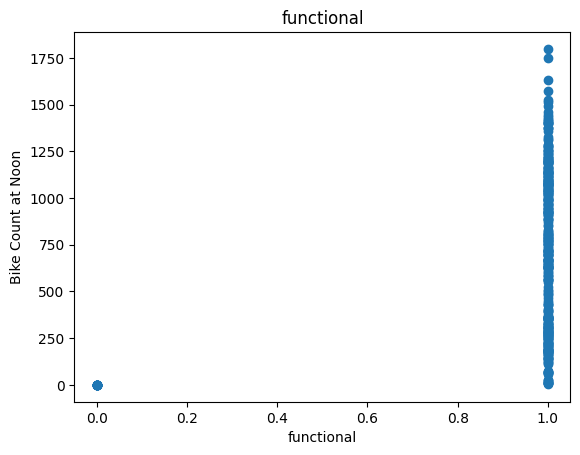

In [48]:
for label in df.columns[1:]:
  plt.scatter(df[label], df['bike_count'])
  plt.title(label)
  plt.ylabel('Bike Count at Noon')
  plt.xlabel(label)
  plt.show()

In [50]:
df = df.drop(['wind', 'visibility', 'functional'], axis = 1)

In [51]:
df.head()

,bike_count,temp,humidity,dew_pt_temp,radiation,rain,snow
12,449,1.7,23,-17.2,1.11,0.0,0.0
36,479,4.3,41,-7.8,1.09,0.0,0.0
60,333,5.8,85,3.4,0.43,0.0,0.0
84,393,-0.3,38,-12.9,1.11,0.0,0.0
108,321,-2.3,25,-19.7,0.00,0.0,0.0


##Train | Validation | Test Datasets

In [57]:
train, val, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [67]:
def get_xy(dataframe, y_label, x_labels=None):
  dataframe = copy.deepcopy(dataframe)
  if x_labels is None:
    X = dataframe[[c for c in dataframe.columns if c != y_label]].values
  else:
    if len(x_labels) == 1:
      X = dataframe[x_labels[0]].values.reshape(-1, 1)
    else:
      X = dataframe[x_labels].values
  y = dataframe[y_label].values.reshape(-1, 1)
  data = np.hstack((X, y))
  return data, X, y

In [59]:
_, X_train_temp, y_train_temp = get_xy(train, 'bike_count', ['temp'])
_, X_val_temp, y_val_temp = get_xy(val, 'bike_count', ['temp'])
_, X_test_temp, y_test_temp = get_xy(test, 'bike_count', ['temp'])

In [60]:
temp_regresser = LinearRegression()
temp_regresser.fit(X_train_temp, y_train_temp)

LinearRegression()

In [61]:
print(temp_regresser.coef_, temp_regresser.intercept_)

[[20.53585018]] [386.53955763]


R^2 Score

In [62]:
print(temp_regresser.score(X_train_temp, y_train_temp))
print(temp_regresser.score(X_val_temp, y_val_temp))

0.3265808099613604
0.2962502099511717


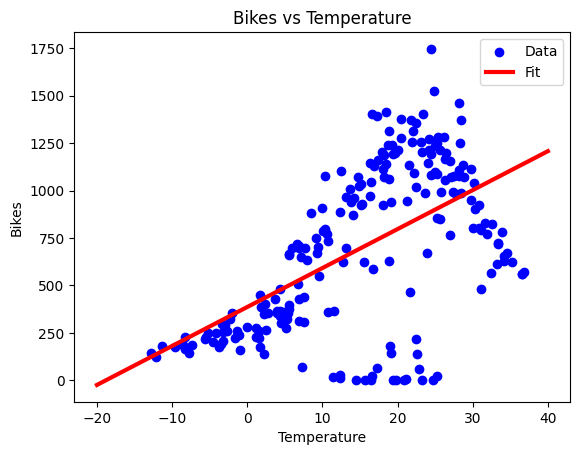

In [65]:
plt.scatter(X_train_temp, y_train_temp, label='Data', color='blue')
x = tf.linspace(-20, 40, 100)
plt.plot(x, temp_regresser.predict(x.numpy().reshape(-1, 1)), label='Fit', color='red', linewidth=3)
plt.legend()
plt.title("Bikes vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Bikes")
plt.show()

##Multiple Linear Regression

In [69]:
_, X_train, y_train = get_xy(train, 'bike_count', df.columns[1:])
_, X_val, y_val = get_xy(val, 'bike_count', df.columns[1:])
_, X_test, y_test = get_xy(test, 'bike_count', df.columns[1:])

In [70]:
all_reg = LinearRegression()
all_reg.fit(X_train, y_train)

LinearRegression()

In [71]:
all_reg.score(X_train, y_train)

0.4720259176045879

Regression with Neural Net

In [72]:
temp_normalizer = tf.keras.layers.Normalization(input_shape = (1,), axis=None)
temp_normalizer.adapt(X_train_temp.reshape(-1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [73]:
temp_nn_model = tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(units=1)
])

In [89]:
temp_nn_model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.1),
                      loss=tf.keras.losses.MeanSquaredError())

In [90]:
history = temp_nn_model.fit(
    X_train_temp, y_train_temp, epochs=1000,
    verbose=0,
    validation_data = (X_val_temp, y_val_temp))

In [91]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('MSE')
  plt.legend()
  plt.grid(True)
  plt.show()

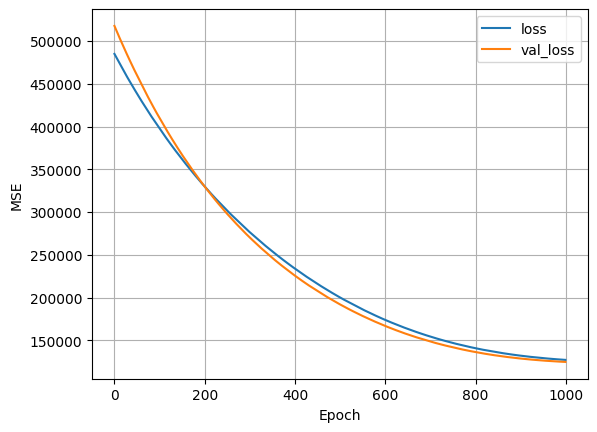

In [92]:
plot_loss(history)

In [88]:
print('Training Loss History:')
print(history.history['loss'])
print('\nValidation Loss History:')
print(history.history['val_loss'])

Training Loss History:
[591388.875, 591275.625, 591156.0625, 591044.5, 590931.5625, 590810.0625, 590700.8125, 590584.125, 590469.625, 590354.3125, 590240.8125, 590124.4375, 590012.9375, 589891.875, 589782.1875, 589663.8125, 589552.3125, 589433.8125, 589323.3125, 589205.875, 589092.625, 588975.5625, 588860.5, 588747.9375, 588629.8125, 588519.6875, 588402.3125, 588288.5625, 588170.5, 588055.4375, 587941.9375, 587829.25, 587711.1875, 587599.875, 587485.0625, 587370.3125, 587254.0625, 587138.875, 587024.625, 586914.5, 586797.125, 586681.5625, 586567.875, 586457.125, 586341.75, 586223.4375, 586113.0625, 586001.0, 585886.1875, 585769.125, 585657.625, 585542.8125, 585426.6875, 585314.375, 585197.875, 585087.3125, 584972.8125, 584857.125, 584743.75, 584626.5, 584516.5625, 584400.0625, 584285.875, 584173.6875, 584059.125, 583943.375, 583830.375, 583717.25, 583600.0625, 583492.6875, 583374.4375, 583260.8125, 583148.875, 583031.3125, 582918.0625, 582805.875, 582693.5, 582574.4375, 582462.75, 5823

In [109]:
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(X_train)

In [110]:
nn_model = tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(units=1)
])

In [111]:
nn_model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.1),
                      loss=tf.keras.losses.MeanSquaredError())

In [96]:
history = nn_model.fit(
    X_train, y_train, epochs=1000,
    verbose=0,
    validation_data = (X_val, y_val))

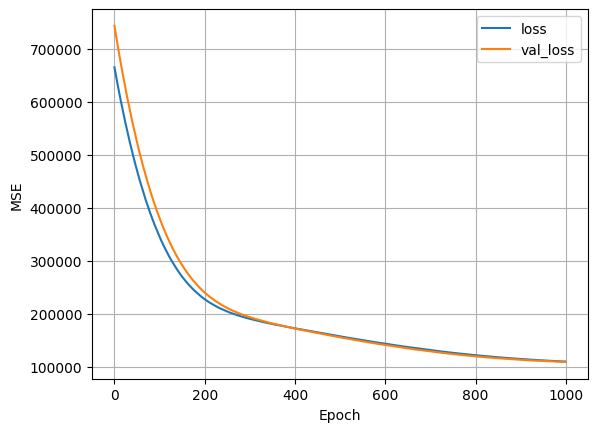

In [97]:
plot_loss(history)

#Neural Net

In [103]:
temp_normalizer = tf.keras.layers.Normalization(input_shape = (1,), axis=None)
temp_normalizer.adapt(X_train_temp.reshape(-1))

_nn_model = tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='relu')
])
_nn_model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.001),
                  loss=tf.keras.losses.MeanSquaredError())
history = _nn_model.fit(
    X_train_temp, y_train_temp, epochs=1000,
    verbose=0,
    validation_data = (X_val_temp, y_val_temp))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


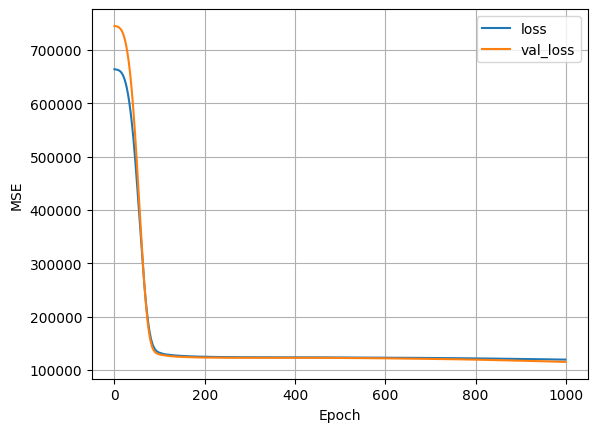

In [104]:
plot_loss(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


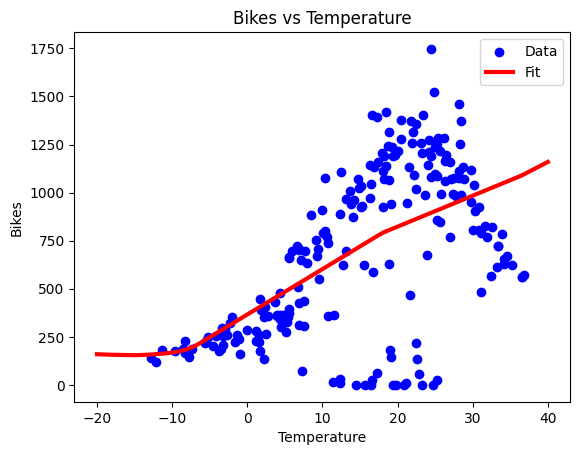

In [105]:
plt.scatter(X_train_temp, y_train_temp, label='Data', color='blue')
x = tf.linspace(-20, 40, 100)
plt.plot(x, _nn_model.predict(x.numpy().reshape(-1, 1)), label='Fit', color='red', linewidth=3)
plt.legend()
plt.title("Bikes vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Bikes")
plt.show()

In [112]:
y_pred_linear = all_reg.predict(X_test)
y_pred_nn = nn_model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step 


In [118]:
def MSE(y_pred, y_real):
  return (np.square(y_pred - y_real)).mean()

In [119]:
print(MSE(y_pred_linear, y_test))

103936.47223449811


In [120]:
print(MSE(y_pred_nn, y_test))

634997.7466693918
